In [1]:
# ==============================================================================
# Seasonal wave climate comparison:
#   ST73141  Chandeleur Islands, Gulf of Mexico
#   ST63268  North Core Banks, Atlantic
# csherwood@usgs.gov, 2026-06-18, generated with Claude Sonnet 4.6
#
# Bulk statistics (no trend analysis) by season and overall.
# Variables: Hs, Tp, wave power P, non-dimensional settling velocity Omega.
#
# Runup (Stockdon et al. 2006, Coast. Eng. 53:573-588):
#   R2% = 1.1 * { 0.35*beta*sqrt(Hs*L0)
#               + sqrt(Hs*L0*(0.563*beta^2 + 0.004)) / 2 }
#   L0 = g*Tp^2 / (2*pi)
#
# Wave power (Holthuijsen 2007, eq. 5.4.17):
#   P = (rho*g^2)/(64*pi) * Hs^2 * Te  [W/m],  Te = Tm/0.90
#
# Non-dimensional settling velocity (Dean 1973, J. Waterw. Port Coast. Ocean
#   Div. 99(WW3):631; Wright & Short 1984, Mar. Geol. 56:93-118):
#   Omega = Hs * Tp / ws
#
# Settling velocity (Ferguson & Church 2004, J. Sediment. Res. 74:933-937):
#   ws = R*g*D50^2 / (C1*nu + sqrt(0.75*C2*R*g*D50^3))
#   R=1.65, C1=18, C2=1.0, nu=1e-6 m^2/s
# ==============================================================================
import os, warnings
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as spstats
warnings.filterwarnings('ignore')

# ── Physical constants ────────────────────────────────────────────────────────
G   = 9.81      # m/s^2
RHO = 1025.0    # kg/m^3
NU  = 1.0e-6    # kinematic viscosity m^2/s (20 deg C)
R_SG = 1.65     # submerged specific gravity (quartz)
C1, C2 = 18.0, 1.0

def ws_ferguson_church(d50_m):
    """Ferguson & Church (2004) settling velocity for natural sand [m/s]."""
    return R_SG*G*d50_m**2 / (C1*NU + np.sqrt(0.75*C2*R_SG*G*d50_m**3))

def stockdon_r2(hs, tp, beta):
    """Stockdon et al. (2006) 2% runup exceedance [m]."""
    L0 = G * tp**2 / (2*np.pi)
    return 1.1*(0.35*beta*np.sqrt(hs*L0)
                + np.sqrt(hs*L0*(0.563*beta**2 + 0.004))/2)

# ── Site configurations ───────────────────────────────────────────────────────
SITES = {
    'Chandeleur': dict(
        station_id = '73141',
        label      = 'Chandeleur Is. (GoM)',
        color      = 'steelblue',
        cache_dir  = r'F:\crs\proj\2026_Chandeleur_fluxes\WIS_cache',
        file_fmt   = 'WIS-ocean_waves_ST{sid}_{yr}{mo:02d}.nc',
        first_year = 1980,
        last_year  = 2023,
        beta       = 0.02,    # low-gradient dissipative barrier
        d50_m      = 0.00025, # 0.25 mm fine sand
    ),
    'NorthCore': dict(
        station_id = '63268',
        label      = 'N. Core Banks (Atlantic)',
        color      = 'firebrick',
        cache_dir  = r'F:\crs\src\storminess\wis_cache',
        file_fmt   = 'WIS-ocean_waves_ST{sid}_{yr}{mo:02d}.nc',
        first_year = 1980,
        last_year  = 2023,
        beta       = 0.05,    # intermediate-to-reflective Atlantic barrier
        d50_m      = 0.00035, # 0.35 mm medium sand
    ),
}

# Pre-compute settling velocities and print site summary
for name, s in SITES.items():
    s['ws'] = ws_ferguson_church(s['d50_m'])
    print(f"{s['label']:30s}  beta={s['beta']:.2f}  "
          f"D50={s['d50_m']*1000:.2f} mm  ws={s['ws']:.4f} m/s")

# Season map: month -> season name and order index
SEASON_MAP  = {12:'Winter',1:'Winter',2:'Winter',
               3:'Spring', 4:'Spring', 5:'Spring',
               6:'Summer', 7:'Summer', 8:'Summer',
               9:'Fall',  10:'Fall',  11:'Fall'}
SEASON_ORDER = ['Winter','Spring','Summer','Fall']
MONTH_ABBR   = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

Chandeleur Is. (GoM)            beta=0.02  D50=0.25 mm  ws=0.0318 m/s
N. Core Banks (Atlantic)        beta=0.05  D50=0.35 mm  ws=0.0486 m/s


In [2]:
# ==============================================================================
# CELL 2 — Load both sites from local cache into a dict of DataFrames
#
# waveTm fallback: Tp/1.28 (JONSWAP Tm01 approx.; Holthuijsen 2007 p.67)
# Years with < 8000 hourly Hs values (< ~91% complete) are excluded.
# ==============================================================================

dfs = {}   # site key -> hourly DataFrame

for name, s in SITES.items():
    records = []
    missing = 0
    for yr in range(s['first_year'], s['last_year']+1):
        for mo in range(1, 13):
            fpath = os.path.join(s['cache_dir'],
                        s['file_fmt'].format(sid=s['station_id'], yr=yr, mo=mo))
            if not os.path.exists(fpath):
                missing += 1
                continue
            with nc.Dataset(fpath) as ds:
                tvar  = ds.variables['time']
                times = nc.num2date(tvar[:], tvar.units,
                            calendar=getattr(tvar,'calendar','standard'))
                hs = ds.variables['waveHs'][:].filled(np.nan)
                tp = ds.variables['waveTp'][:].filled(np.nan)
                tm = (ds.variables['waveTm'][:].filled(np.nan)
                      if 'waveTm' in ds.variables else tp/1.28)
            dts = pd.to_datetime([t.isoformat() for t in times])
            records.append(pd.DataFrame({'Hs':hs,'Tp':tp,'Tm':tm}, index=dts))

    df = pd.concat(records).sort_index()
    df = df[~df.index.duplicated()]

    # Derived quantities
    df['R2']    = stockdon_r2(df['Hs'], df['Tp'], s['beta'])
    Te          = df['Tm'] / 0.90
    df['P_kW']  = (RHO*G**2)/(64*np.pi) * df['Hs']**2 * Te / 1000
    df['Omega'] = df['Hs'] * df['Tp'] / s['ws']
    df['month'] = df.index.month
    df['season'] = df['month'].map(SEASON_MAP)

    # Drop incomplete years
    year_counts = df.groupby(df.index.year)['Hs'].count()
    good_years  = year_counts[year_counts >= 8000].index
    df = df[df.index.year.isin(good_years)]

    dfs[name] = df
    print(f"{s['label']:30s}  missing files: {missing:3d}  "
          f"record: {df.index[0].date()} – {df.index[-1].date()}  "
          f"({len(df):,} hrs)")

Chandeleur Is. (GoM)            missing files:   0  record: 1980-01-01 – 2023-12-31  (385,703 hrs)
N. Core Banks (Atlantic)        missing files:   0  record: 1980-01-01 – 2023-12-31  (385,703 hrs)


In [3]:
# ==============================================================================
# CELL 3 — Bulk statistics: overall and by season
#
# Percentiles: p10, p25, median, p75, p90, p95, p99, max.
# Results stored in a MultiIndex DataFrame for easy tabulation.
# ==============================================================================

VARS   = ['Hs','Tp','P_kW','Omega','R2']
STATS  = ['mean','std','p10','p25','median','p75','p90','p95','p99','max']
PCT_MAP = {'p10':0.10,'p25':0.25,'median':0.50,'p75':0.75,
           'p90':0.90,'p95':0.95,'p99':0.99}

def compute_stats(series):
    out = {'mean': series.mean(), 'std': series.std(),
           'max':  series.max()}
    for k, p in PCT_MAP.items():
        out[k] = series.quantile(p)
    return pd.Series(out)[STATS]

# Build a dict: site -> var -> {season/overall -> stats Series}
all_stats = {}
for name, df in dfs.items():
    all_stats[name] = {}
    for var in VARS:
        rows = {'Overall': compute_stats(df[var].dropna())}
        for seas in SEASON_ORDER:
            rows[seas] = compute_stats(df.loc[df['season']==seas, var].dropna())
        all_stats[name][var] = pd.DataFrame(rows, index=STATS).T  # shape: 5 × 10

# Print summary for Hs as a sanity check
for name, s in SITES.items():
    print(f"\n── Hs (m) — {s['label']} ──")
    print(all_stats[name]['Hs'].round(3).to_string())


── Hs (m) — Chandeleur Is. (GoM) ──
          mean    std    p10    p25  median    p75    p90    p95    p99     max
Overall  0.753  0.585  0.156  0.344   0.617  1.031  1.500  1.820  2.641  10.531
Winter   0.932  0.596  0.250  0.500   0.844  1.250  1.727  2.062  2.719   5.242
Spring   0.789  0.517  0.219  0.422   0.688  1.062  1.477  1.750  2.430   4.180
Summer   0.478  0.452  0.117  0.211   0.383  0.594  0.891  1.188  2.078  10.531
Fall     0.817  0.658  0.172  0.359   0.680  1.109  1.594  1.922  3.023  10.172

── Hs (m) — N. Core Banks (Atlantic) ──
          mean    std    p10    p25  median    p75    p90    p95    p99    max
Overall  1.192  0.603  0.594  0.773   1.062  1.461  1.945  2.312  3.266  9.094
Winter   1.310  0.620  0.633  0.867   1.203  1.633  2.109  2.484  3.312  6.695
Spring   1.245  0.590  0.633  0.828   1.125  1.523  2.016  2.375  3.211  7.141
Summer   0.968  0.437  0.555  0.695   0.883  1.148  1.453  1.672  2.297  8.984
Fall     1.248  0.681  0.562  0.781   1.117  1.

In [4]:
# ==============================================================================
# CELL 4 — Combined comparison table (Overall + 4 seasons × 5 variables)
#
# Prints a side-by-side table: Chandeleur | North Core Banks,
# with the ratio (NCore / Chandeleur) for quick reference.
# ==============================================================================

VAR_UNITS = {'Hs':'m', 'Tp':'s', 'P_kW':'kW/m', 'Omega':'-', 'R2':'m'}
SHOW_STATS = ['mean','median','p90','p95','max']

for var in VARS:
    unit = VAR_UNITS[var]
    print(f"\n{'='*72}")
    print(f"  {var} ({unit})")
    print(f"{'='*72}")
    hdr = f"{'Period':<10}  {'Stat':<8}"
    for name, s in SITES.items():
        hdr += f"  {s['label']:>24}"
    hdr += f"  {'Ratio NC/CL':>12}"
    print(hdr)
    print('─'*len(hdr))
    for period in ['Overall'] + SEASON_ORDER:
        for i, stat in enumerate(SHOW_STATS):
            row = f"{'':10}  {stat:<8}" if i > 0 else f"{period:<10}  {stat:<8}"
            vals = {}
            for name in SITES:
                v = all_stats[name][var].loc[period, stat]
                vals[name] = v
                row += f"  {v:>24.3f}"
            v_cl = vals['Chandeleur']
            v_nc = vals['NorthCore']
            ratio = v_nc/v_cl if v_cl != 0 else np.nan
            row += f"  {ratio:>12.2f}"
            print(row)
        print()


  Hs (m)
Period      Stat          Chandeleur Is. (GoM)  N. Core Banks (Atlantic)   Ratio NC/CL
──────────────────────────────────────────────────────────────────────────────────────
Overall     mean                         0.753                     1.192          1.58
            median                       0.617                     1.062          1.72
            p90                          1.500                     1.945          1.30
            p95                          1.820                     2.312          1.27
            max                         10.531                     9.094          0.86

Winter      mean                         0.932                     1.310          1.41
            median                       0.844                     1.203          1.43
            p90                          1.727                     2.109          1.22
            p95                          2.062                     2.484          1.20
            max                 

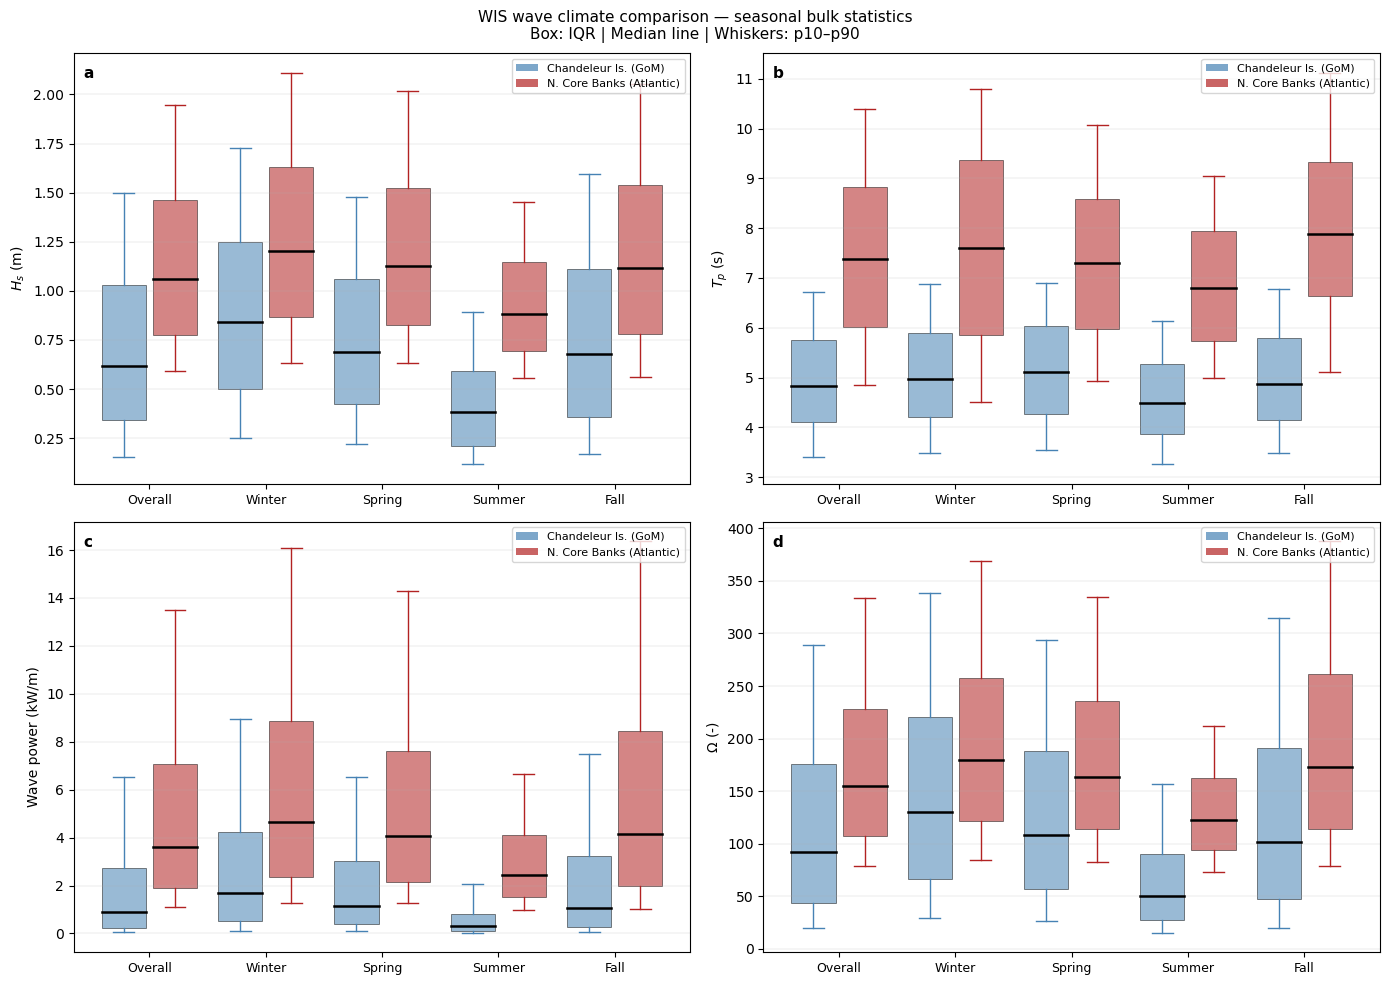

In [5]:
# ==============================================================================
# CELL 5 — Box-and-whisker comparison: Overall + 4 seasons (4-panel figure)
#
# Each panel shows Hs, Tp, P, Omega side-by-side for the two sites.
# Box: IQR; whiskers: p10–p90; notch: 95% CI on median.
# Groups: Overall / Winter / Spring / Summer / Fall.
# Panels labelled a–d.
# ==============================================================================

GROUPS   = ['Overall'] + SEASON_ORDER
site_keys = list(SITES.keys())

panel_vars = [
    ('Hs',    '$H_s$ (m)',       'steelblue',    'firebrick'),
    ('Tp',    '$T_p$ (s)',       'steelblue',    'firebrick'),
    ('P_kW',  'Wave power (kW/m)','steelblue',   'firebrick'),
    ('Omega', '$\\Omega$ (-)',   'steelblue',    'firebrick'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
letters = 'abcd'

for ax, (var, ylabel, c_cl, c_nc), ltr in zip(axes.flat, panel_vars, letters):
    n_groups = len(GROUPS)
    x_cl = np.arange(n_groups) - 0.22   # Chandeleur positions
    x_nc = np.arange(n_groups) + 0.22   # North Core positions

    for x_pos, site_key, col in [(x_cl,'Chandeleur',c_cl),(x_nc,'NorthCore',c_nc)]:
        df = dfs[site_key]
        data_groups = []
        for grp in GROUPS:
            if grp == 'Overall':
                data_groups.append(df[var].dropna().values)
            else:
                data_groups.append(df.loc[df['season']==grp, var].dropna().values)

        # Draw each group as a mini box
        for xi, data in zip(x_pos, data_groups):
            q10,q25,q50,q75,q90 = np.percentile(data,[10,25,50,75,90])
            # IQR box
            ax.bar(xi, q75-q25, bottom=q25, width=0.38,
                   color=col, alpha=0.55, edgecolor='k', lw=0.6)
            # Median line
            ax.plot([xi-0.19, xi+0.19], [q50, q50], '-', color='k', lw=1.8)
            # p10–p90 whiskers
            ax.plot([xi, xi], [q10, q25], '-', color=col, lw=1.0)
            ax.plot([xi, xi], [q75, q90], '-', color=col, lw=1.0)
            ax.plot([xi-0.09, xi+0.09], [q10,q10], '-', color=col, lw=1.0)
            ax.plot([xi-0.09, xi+0.09], [q90,q90], '-', color=col, lw=1.0)

    ax.set_xticks(np.arange(n_groups))
    ax.set_xticklabels(GROUPS, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(axis='y', lw=0.35, alpha=0.5)
    ax.text(0.015, 0.97, ltr, transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')

    # Legend patches (once per panel)
    from matplotlib.patches import Patch
    handles = [
        Patch(facecolor=c_cl, alpha=0.7, label=SITES['Chandeleur']['label']),
        Patch(facecolor=c_nc, alpha=0.7, label=SITES['NorthCore']['label']),
    ]
    ax.legend(handles=handles, fontsize=8, loc='upper right')

fig.suptitle('WIS wave climate comparison — seasonal bulk statistics\n'
             'Box: IQR | Median line | Whiskers: p10–p90',
             fontsize=11)
plt.tight_layout()
plt.savefig('WIS_seasonal_boxplot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

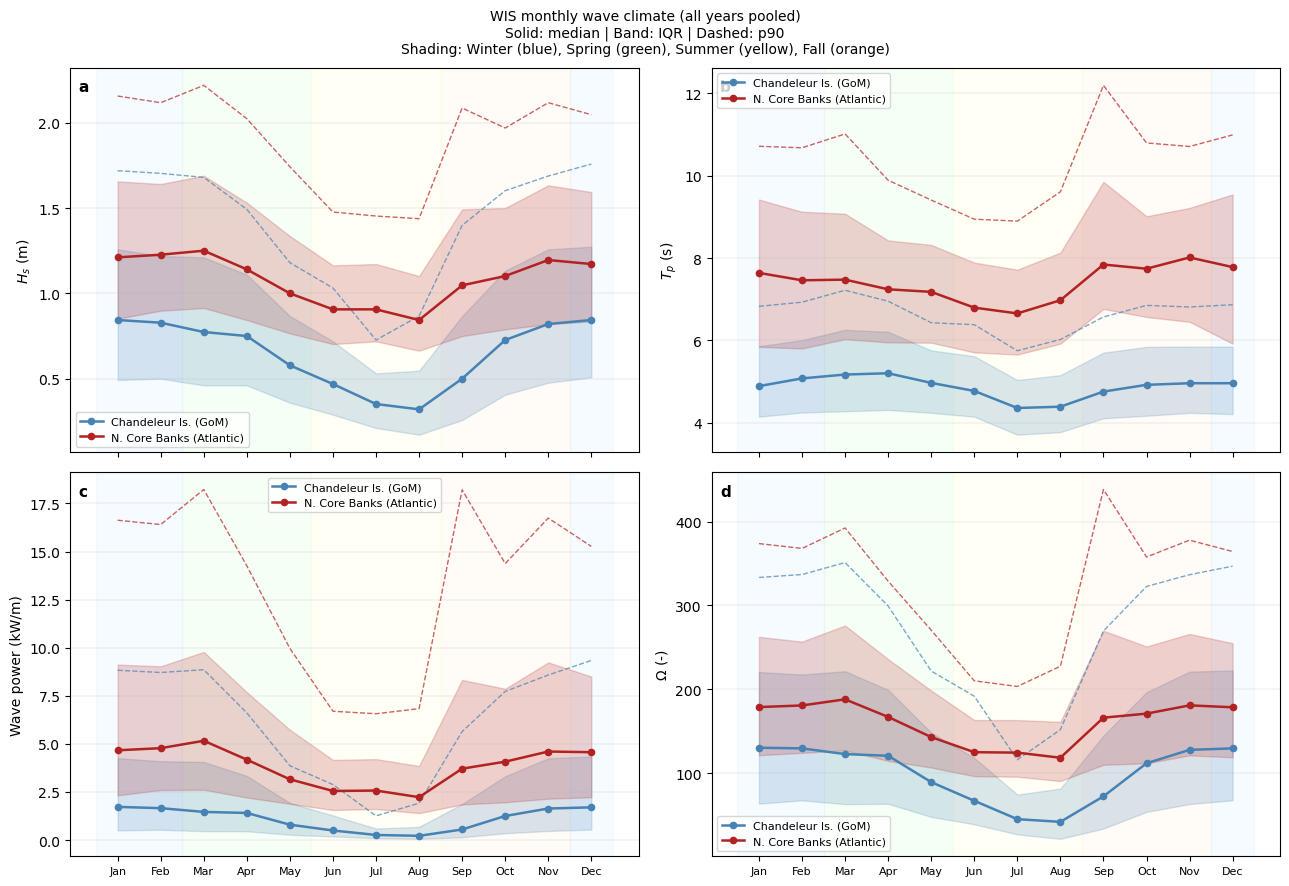

In [6]:
# ==============================================================================
# CELL 6 — Monthly median climatology (all years pooled)
#
# Shows the seasonal cycle of Hs, Tp, P, and Omega for both sites.
# Shaded band: IQR (p25–p75).  Dashed line: p90.
# This condenses seasonal structure more finely than the 4-season grouping.
# Panels labelled a–d.
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
letters = 'abcd'
x = np.arange(1, 13)

panel_vars = [
    ('Hs',    '$H_s$ (m)'),
    ('Tp',    '$T_p$ (s)'),
    ('P_kW',  'Wave power (kW/m)'),
    ('Omega', '$\\Omega$ (-)'),
]

for ax, (var, ylabel), ltr in zip(axes.flat, panel_vars, letters):
    for name, s in SITES.items():
        df  = dfs[name]
        grp = df.groupby('month')[var]
        med = grp.median()
        p25 = grp.quantile(0.25)
        p75 = grp.quantile(0.75)
        p90 = grp.quantile(0.90)
        col = s['color']
        ax.fill_between(x, p25, p75, alpha=0.20, color=col)
        ax.plot(x, med, '-o', color=col, lw=1.8, ms=4.5, label=s['label'])
        ax.plot(x, p90, '--', color=col, lw=1.0, alpha=0.70)

    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(MONTH_ABBR, fontsize=8)
    ax.grid(axis='y', lw=0.35, alpha=0.5)
    ax.legend(fontsize=8)
    ax.text(0.015, 0.97, ltr, transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')

# Season background shading
season_spans = [
    (12, 2, 'Winter', '#aaddff'),
    (3,  5, 'Spring', '#aaffaa'),
    (6,  8, 'Summer', '#ffffaa'),
    (9, 11, 'Fall',   '#ffddaa'),
]
for ax in axes.flat:
    ylo, yhi = ax.get_ylim()
    # Winter: Dec (month 12) wraps; plot Dec as a half-span at right edge
    ax.axvspan(0.5, 2.5,  alpha=0.10, color='#aaddff', zorder=0)
    ax.axvspan(2.5, 5.5,  alpha=0.10, color='#aaffaa', zorder=0)
    ax.axvspan(5.5, 8.5,  alpha=0.10, color='#ffffaa', zorder=0)
    ax.axvspan(8.5, 11.5, alpha=0.10, color='#ffddaa', zorder=0)
    ax.axvspan(11.5,12.5, alpha=0.10, color='#aaddff', zorder=0)

fig.suptitle('WIS monthly wave climate (all years pooled)\n'
             'Solid: median | Band: IQR | Dashed: p90\n'
             'Shading: Winter (blue), Spring (green), Summer (yellow), Fall (orange)',
             fontsize=10)
plt.tight_layout()
plt.savefig('WIS_monthly_climatology_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

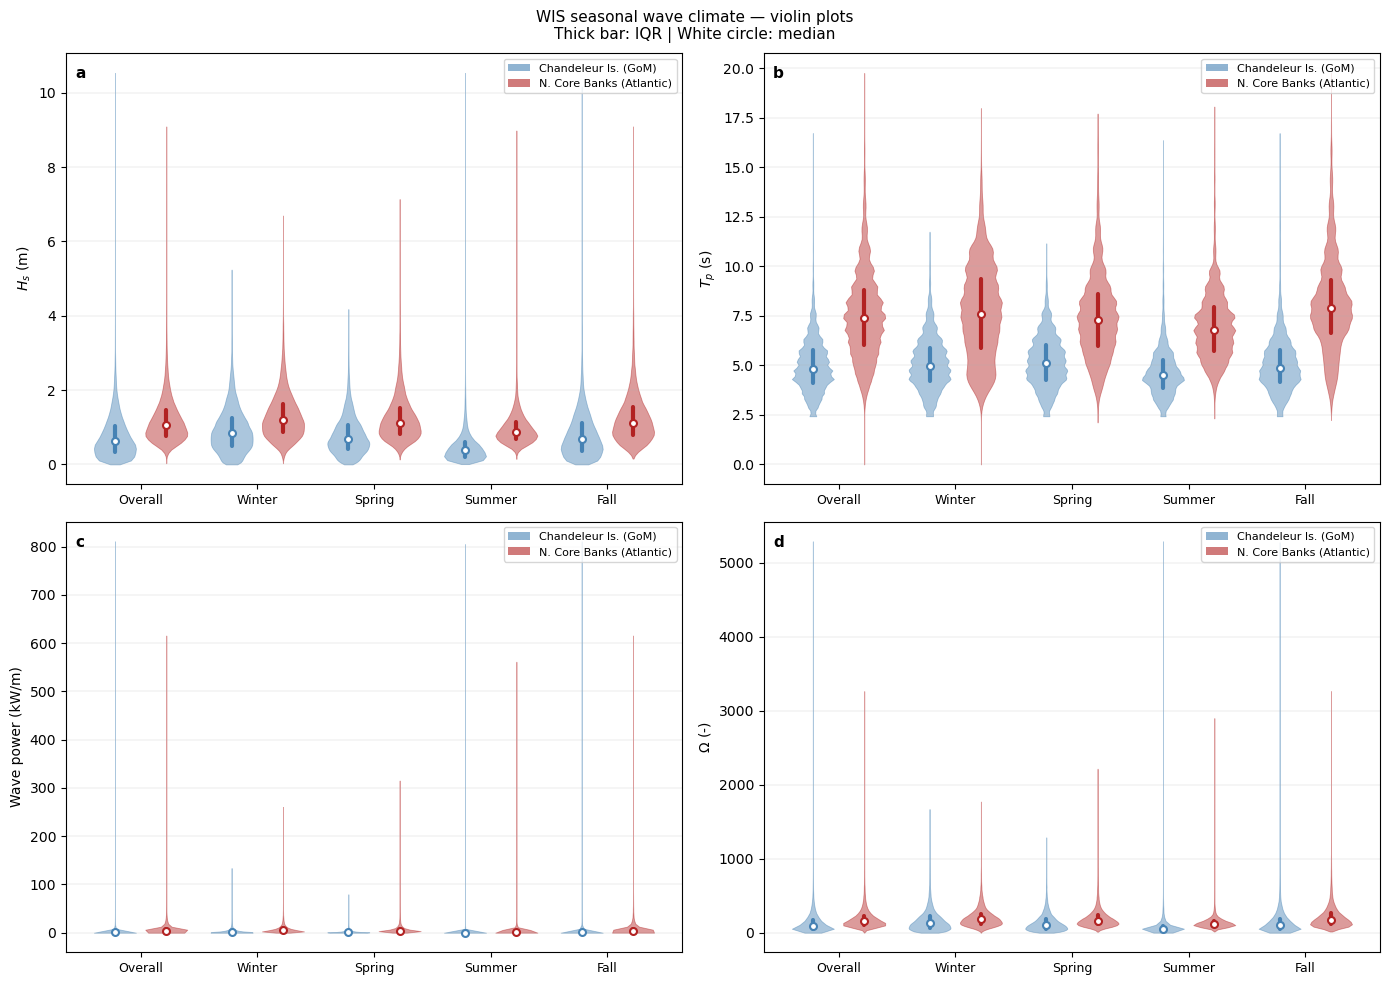

In [7]:
# ==============================================================================
# CELL 7 — Violin plots: full distribution by season (4-panel)
#
# Violins show the complete PDF shape (especially the upper tail) more
# faithfully than box plots.  Inner quartile lines drawn explicitly.
# Panels labelled a–d.
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
letters = 'abcd'
GROUPS  = ['Overall'] + SEASON_ORDER

panel_vars = [
    ('Hs',    '$H_s$ (m)'),
    ('Tp',    '$T_p$ (s)'),
    ('P_kW',  'Wave power (kW/m)'),
    ('Omega', '$\\Omega$ (-)'),
]

for ax, (var, ylabel), ltr in zip(axes.flat, panel_vars, letters):
    n_groups  = len(GROUPS)
    positions_cl = np.arange(n_groups) - 0.22
    positions_nc = np.arange(n_groups) + 0.22
    vwidth = 0.36

    for pos_arr, site_key in [(positions_cl,'Chandeleur'),(positions_nc,'NorthCore')]:
        df  = dfs[site_key]
        col = SITES[site_key]['color']
        data_list = []
        for grp in GROUPS:
            if grp == 'Overall':
                data_list.append(df[var].dropna().values)
            else:
                data_list.append(df.loc[df['season']==grp, var].dropna().values)

        vp = ax.violinplot(data_list, positions=pos_arr, widths=vwidth,
                           showmedians=False, showextrema=False)
        for body in vp['bodies']:
            body.set_facecolor(col)
            body.set_alpha(0.45)
            body.set_edgecolor(col)
            body.set_linewidth(0.6)

        # Overlay quartile lines
        for xi, data in zip(pos_arr, data_list):
            q25,q50,q75 = np.percentile(data,[25,50,75])
            ax.plot([xi,xi],[q25,q75],'-',color=col,lw=3.0,solid_capstyle='round')
            ax.plot(xi, q50, 'o', color='white', ms=5, mec=col, mew=1.5, zorder=5)

    ax.set_xticks(np.arange(n_groups))
    ax.set_xticklabels(GROUPS, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(axis='y', lw=0.35, alpha=0.5)
    ax.text(0.015, 0.97, ltr, transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')

    from matplotlib.patches import Patch
    handles = [
        Patch(facecolor=SITES['Chandeleur']['color'], alpha=0.6,
              label=SITES['Chandeleur']['label']),
        Patch(facecolor=SITES['NorthCore']['color'],  alpha=0.6,
              label=SITES['NorthCore']['label']),
    ]
    ax.legend(handles=handles, fontsize=8, loc='upper right')

fig.suptitle('WIS seasonal wave climate — violin plots\n'
             'Thick bar: IQR | White circle: median',
             fontsize=11)
plt.tight_layout()
plt.savefig('WIS_seasonal_violin_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

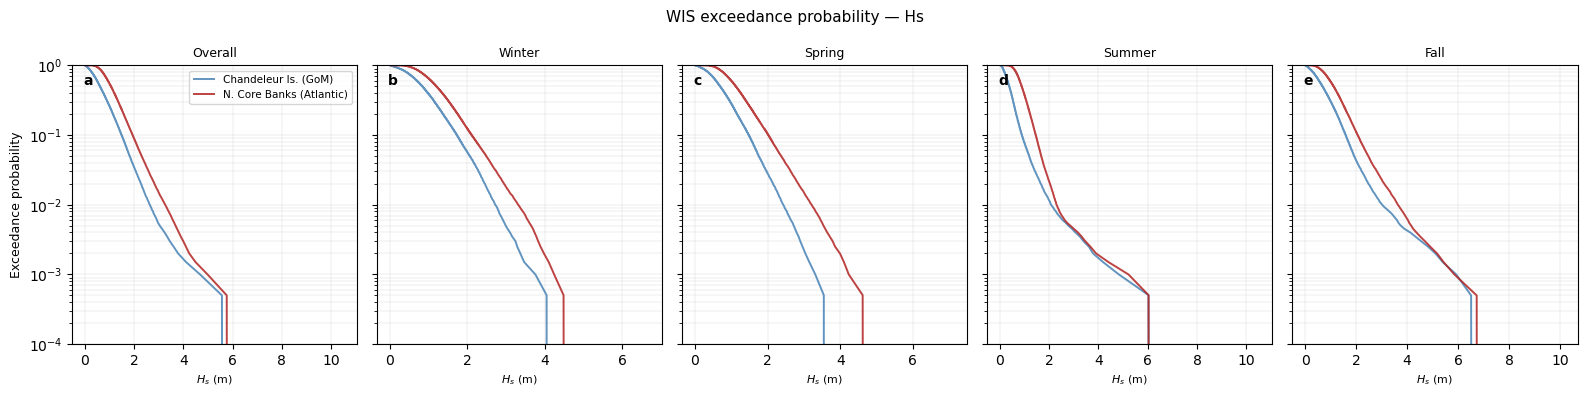

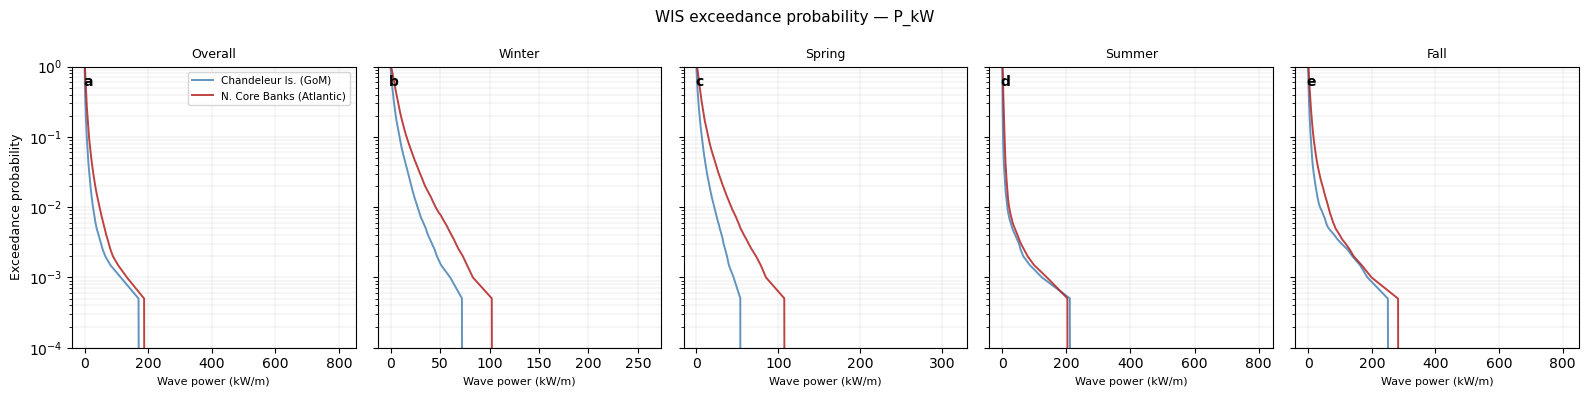

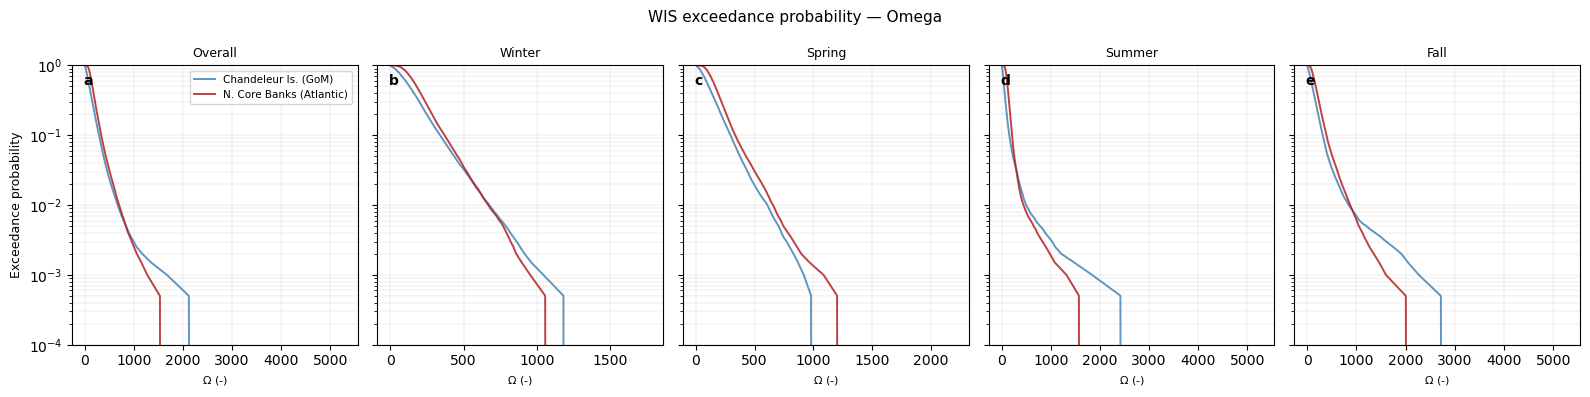

In [8]:
# ==============================================================================
# CELL 8 — Exceedance probability curves by season (4-panel)
#
# Log-scale y-axis (exceedance probability) vs variable value.
# Separate line per site; separate panel per season + Overall.
# Useful for comparing upper tails (design events) across sites and seasons.
# Panels labelled a–e.
# ==============================================================================

EXCEEDANCE_VARS = [
    ('Hs',   '$H_s$ (m)',        np.linspace(0,   9,  300)),
    ('P_kW', 'Wave power (kW/m)',np.linspace(0, 200,  300)),
    ('Omega','$\\Omega$ (-)',    np.linspace(0, 300,  300)),
]

for var, xlabel, xgrid in EXCEEDANCE_VARS:
    fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)
    letters_e = 'abcde'

    for ax, grp, ltr in zip(axes, ['Overall']+SEASON_ORDER, letters_e):
        for name, s in SITES.items():
            df = dfs[name]
            if grp == 'Overall':
                data = df[var].dropna().values
            else:
                data = df.loc[df['season']==grp, var].dropna().values

            # Empirical CCDF
            data_sorted = np.sort(data)
            exceedance  = 1 - np.arange(1, len(data)+1) / len(data)
            # Subsample for plotting efficiency (~2000 points)
            idx = np.unique(np.round(np.linspace(0, len(data)-1, 2000)).astype(int))
            ax.semilogy(data_sorted[idx], exceedance[idx],
                        '-', color=s['color'], lw=1.4, alpha=0.85,
                        label=s['label'])

        ax.set_xlabel(xlabel, fontsize=8)
        ax.set_title(grp, fontsize=9)
        ax.grid(True, which='both', lw=0.3, alpha=0.5)
        ax.set_ylim(1e-4, 1.0)
        ax.yaxis.set_major_formatter(mticker.LogFormatterSciNotation())
        ax.text(0.04, 0.97, ltr, transform=ax.transAxes,
                fontsize=10, fontweight='bold', va='top')
        if ax == axes[0]:
            ax.set_ylabel('Exceedance probability', fontsize=9)
            ax.legend(fontsize=7.5)

    fig.suptitle(f'WIS exceedance probability — {var}', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'WIS_exceedance_{var}.png', dpi=150, bbox_inches='tight')
    plt.show()

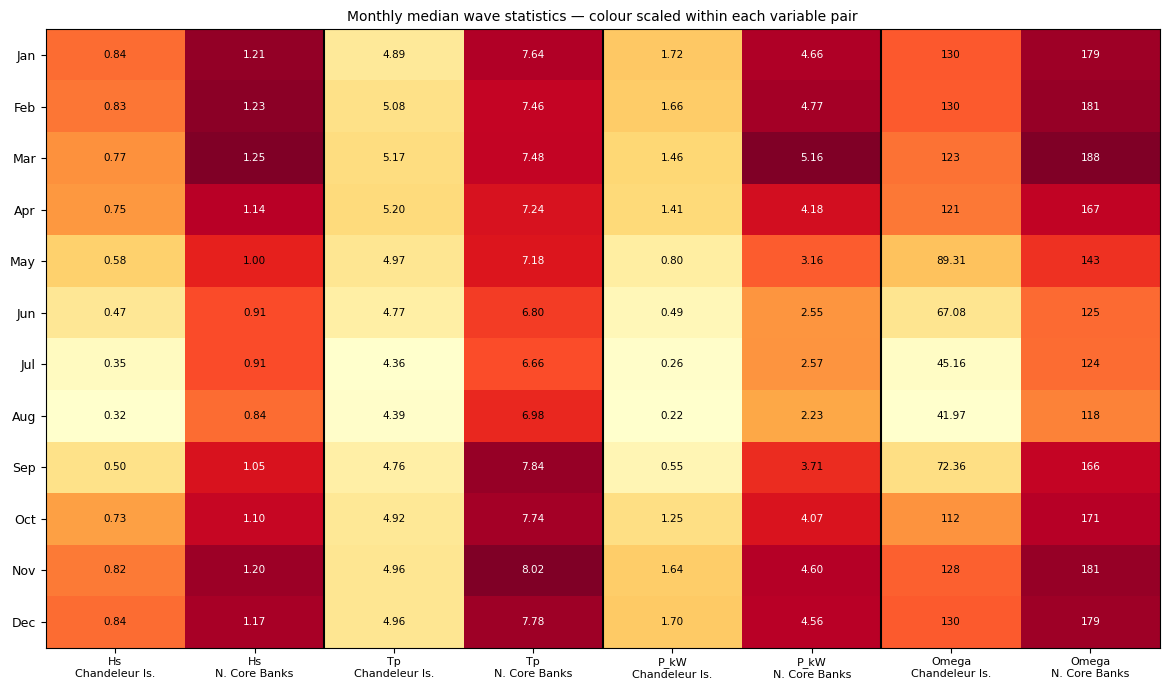

In [9]:
# ==============================================================================
# CELL 9 — Heatmap: monthly median statistics side-by-side
#
# Rows = months; columns = variables × sites.
# Colour-scaled within each variable column pair so relative differences
# are immediately visible.  Values printed in each cell.
# ==============================================================================

HMAP_VARS  = [('Hs','m'),('Tp','s'),('P_kW','kW/m'),('Omega','-')]
site_keys  = list(SITES.keys())
site_labels = [SITES[k]['label'] for k in site_keys]

# Build data matrices: shape (12, n_vars×n_sites)
col_labels = []
matrices   = []

for var, unit in HMAP_VARS:
    for key in site_keys:
        df  = dfs[key]
        med = df.groupby('month')[var].median().values  # shape (12,)
        matrices.append(med)
        col_labels.append(f"{var}\n{SITES[key]['label'].split('(')[0].strip()}")

data_mat = np.column_stack(matrices)   # (12, n_cols)
n_rows, n_cols = data_mat.shape

fig, ax = plt.subplots(figsize=(n_cols*1.35 + 1, 7))

# Normalize each pair of columns (variable) to [0,1] for color
cdata = np.zeros_like(data_mat)
n_sites = len(site_keys)
n_var_cols = len(HMAP_VARS)
for v in range(n_var_cols):
    cols = slice(v*n_sites, (v+1)*n_sites)
    block = data_mat[:, cols]
    cdata[:, cols] = (block - block.min()) / (block.max() - block.min() + 1e-12)

im = ax.imshow(cdata, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)

# Annotate cells
for i in range(n_rows):
    for j in range(n_cols):
        v = data_mat[i, j]
        fmt = '.2f' if v < 100 else '.0f'
        ax.text(j, i, f'{v:{fmt}}', ha='center', va='center', fontsize=7.5,
                color='k' if cdata[i,j] < 0.75 else 'white')

# Vertical separators between variable groups
for v in range(1, n_var_cols):
    ax.axvline(v*n_sites - 0.5, color='k', lw=1.5)

ax.set_yticks(range(12))
ax.set_yticklabels(MONTH_ABBR, fontsize=9)
ax.set_xticks(range(n_cols))
ax.set_xticklabels(col_labels, fontsize=8)
ax.set_title('Monthly median wave statistics — colour scaled within each variable pair',
             fontsize=10)
plt.tight_layout()
plt.savefig('WIS_monthly_heatmap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

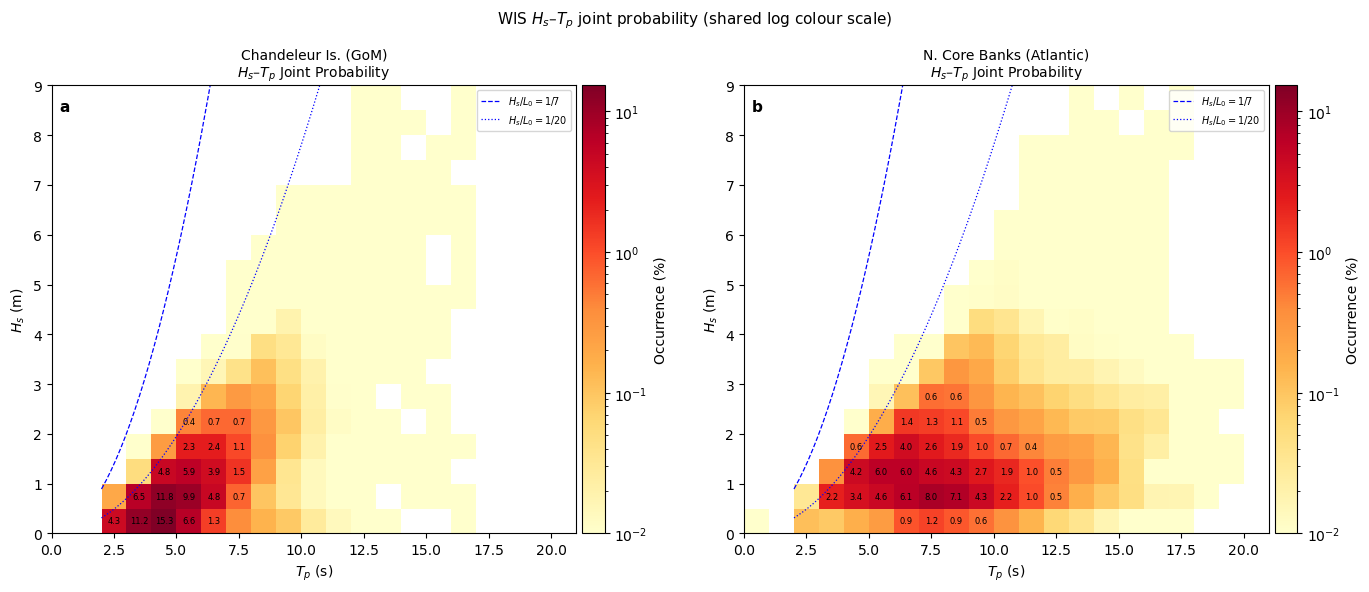

In [10]:
# ==============================================================================
# CELL 10 — Hs–Tp joint probability: side-by-side for both sites (Overall)
#
# Shared colour scale (log-normalised % occurrence) for direct comparison.
# Deep-water steepness limits overlaid on both panels.
# Panels labelled a–b.
# ==============================================================================

Hs_edges = np.arange(0, 9.5, 0.5)
Tp_edges = np.arange(0, 22,  1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
letters = 'ab'

freq_pcts = []
for name, s in SITES.items():
    df  = dfs[name]
    val = df[['Hs','Tp']].dropna()
    counts, _, _ = np.histogram2d(val['Hs'], val['Tp'],
                                   bins=[Hs_edges, Tp_edges])
    freq_pcts.append(counts / counts.sum() * 100)

vmax = max(f.max() for f in freq_pcts)
Tp_line = np.linspace(2, Tp_edges[-1], 200)
L0_line = G * Tp_line**2 / (2*np.pi)

for ax, (name, s), freq, ltr in zip(axes, SITES.items(), freq_pcts, letters):
    import matplotlib.colors as mcolors
    freq_m = np.ma.masked_where(freq == 0, freq)
    cmap   = plt.cm.YlOrRd.copy(); cmap.set_bad('white')
    im = ax.pcolormesh(Tp_edges, Hs_edges, freq_m, cmap=cmap,
                       norm=mcolors.LogNorm(vmin=0.01, vmax=vmax))
    plt.colorbar(im, ax=ax, label='Occurrence (%)', pad=0.01)

    Hs_mids = 0.5*(Hs_edges[:-1]+Hs_edges[1:])
    Tp_mids = 0.5*(Tp_edges[:-1]+Tp_edges[1:])
    for i, hm in enumerate(Hs_mids):
        for j, tm in enumerate(Tp_mids):
            v = freq[i,j]
            if v >= 0.4:
                ax.text(tm, hm, f'{v:.1f}', ha='center', va='center',
                        fontsize=6, color='k')

    ax.plot(Tp_line, L0_line/7,  'b--', lw=0.9, label='$H_s/L_0=1/7$')
    ax.plot(Tp_line, L0_line/20, 'b:',  lw=0.9, label='$H_s/L_0=1/20$')
    ax.set_xlabel('$T_p$ (s)', fontsize=10)
    ax.set_ylabel('$H_s$ (m)', fontsize=10)
    ax.set_title(f"{s['label']}\n$H_s$–$T_p$ Joint Probability", fontsize=10)
    ax.set_xlim(Tp_edges[0], Tp_edges[-1])
    ax.set_ylim(Hs_edges[0], Hs_edges[-1])
    ax.legend(fontsize=7)
    ax.text(0.015, 0.97, ltr, transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')

fig.suptitle('WIS $H_s$–$T_p$ joint probability (shared log colour scale)',
             fontsize=11)
plt.tight_layout()
plt.savefig('WIS_HsTp_joint_comparison.png', dpi=150, bbox_inches='tight')
plt.show()